# Satellite IR CNN for Tropical Cyclone Rapid Intensification (RI)
### Hybrid CNN (MERG-IR imagery) + Tabular (IMD best-track) fusion model — SIH

This notebook extends the RI pipeline from `TC2.ipynb` with a deep-learning
branch that reads raw satellite infrared brightness-temperature imagery,
fused with your existing tabular best-track features.

**Pipeline:** IMD best-track (via `imdtrack`) -> RI_24h labels -> match to
MERG-IR `.nc4` snapshots -> crop 400km patches centered on the storm ->
train a hybrid CNN+MLP classifier with focal loss.


In [1]:
import sys, os
sys.path.insert(0, os.path.join('..','data'))
sys.path.insert(0, os.path.join('..','models'))
sys.path.insert(0, '..')
import numpy as np, pandas as pd
import matplotlib.pyplot as plt


## 1. Rebuild the IMD Rapid Intensification tabular dataset

In [2]:
from build_ri_dataset import build

ri_bob = build(basin_filter="BOB")
valid = ri_bob["RI_24h"].notna()

print("BoB fixes:", ri_bob.shape[0], "| storms:", ri_bob["storm_id"].nunique())
print("Valid-target rows:", valid.sum())
print(ri_bob.loc[valid, "RI_24h"].value_counts())
print(f"RI positive rate: {ri_bob.loc[valid,'RI_24h'].mean()*100:.2f}%")


BoB fixes: 5009 | storms: 291
Valid-target rows: 3091
RI_24h
0.0    2922
1.0     169
Name: count, dtype: int64
RI positive rate: 5.47%


## 2. Match uploaded MERG-IR files to storm fixes and extract IR patches

Point `NC_FOLDER` at wherever you've downloaded MERG-IR `.nc4` files (start with the 11 sample files; scale up with `data/download_mergir.py`).

In [3]:
from extract_ir_patches import build_labeled_patch_dataset

NC_FOLDER = "/mnt/user-data/uploads"   # <-- point this at your full archive once downloaded
data = build_labeled_patch_dataset(ri_bob, NC_FOLDER)

print("Matched patches:", data["X"].shape)
print("Label counts:", np.unique(data["y"], return_counts=True))
data["meta"]


Matched patches: (11, 99, 99)
Label counts: (array([0., 1.], dtype=float32), array([5, 6]))


,storm_id,datetime_utc,matched_file_time,time_offset_min,latitude,longitude,max_wind_kt,RI_24h
0,1998-008,1998-11-14 03:00:00,1998-11-14 03:00:00,0.0,13.5,86.5,30.0,1.0
1,1999-001,1999-02-01 03:00:00,1999-02-01 03:00:00,0.0,9.0,89.0,25.0,0.0
2,1999-007,1999-10-27 06:00:00,1999-10-27 06:00:00,0.0,16.5,91.5,55.0,1.0
3,2000-004,2000-10-25 12:00:00,2000-10-25 12:00:00,0.0,14.0,92.5,25.0,0.0
4,2000-005,2000-11-27 06:00:00,2000-11-27 06:00:00,0.0,11.0,87.0,30.0,1.0
5,2000-006,2000-12-24 06:00:00,2000-12-24 06:00:00,0.0,8.5,84.0,30.0,0.0
6,2020-001,2020-05-17 09:00:00,2020-05-17 08:30:00,30.0,11.7,86.0,65.0,1.0
7,2020-001,2020-05-17 18:00:00,2020-05-17 19:00:00,60.0,12.5,86.1,80.0,1.0
8,2020-001,2020-05-17 21:00:00,2020-05-17 19:30:00,90.0,12.9,86.4,90.0,1.0
9,2020-001,2020-05-18 03:00:00,2020-05-18 03:00:00,0.0,13.3,86.2,115.0,0.0


## 3. Visualize the IR patches

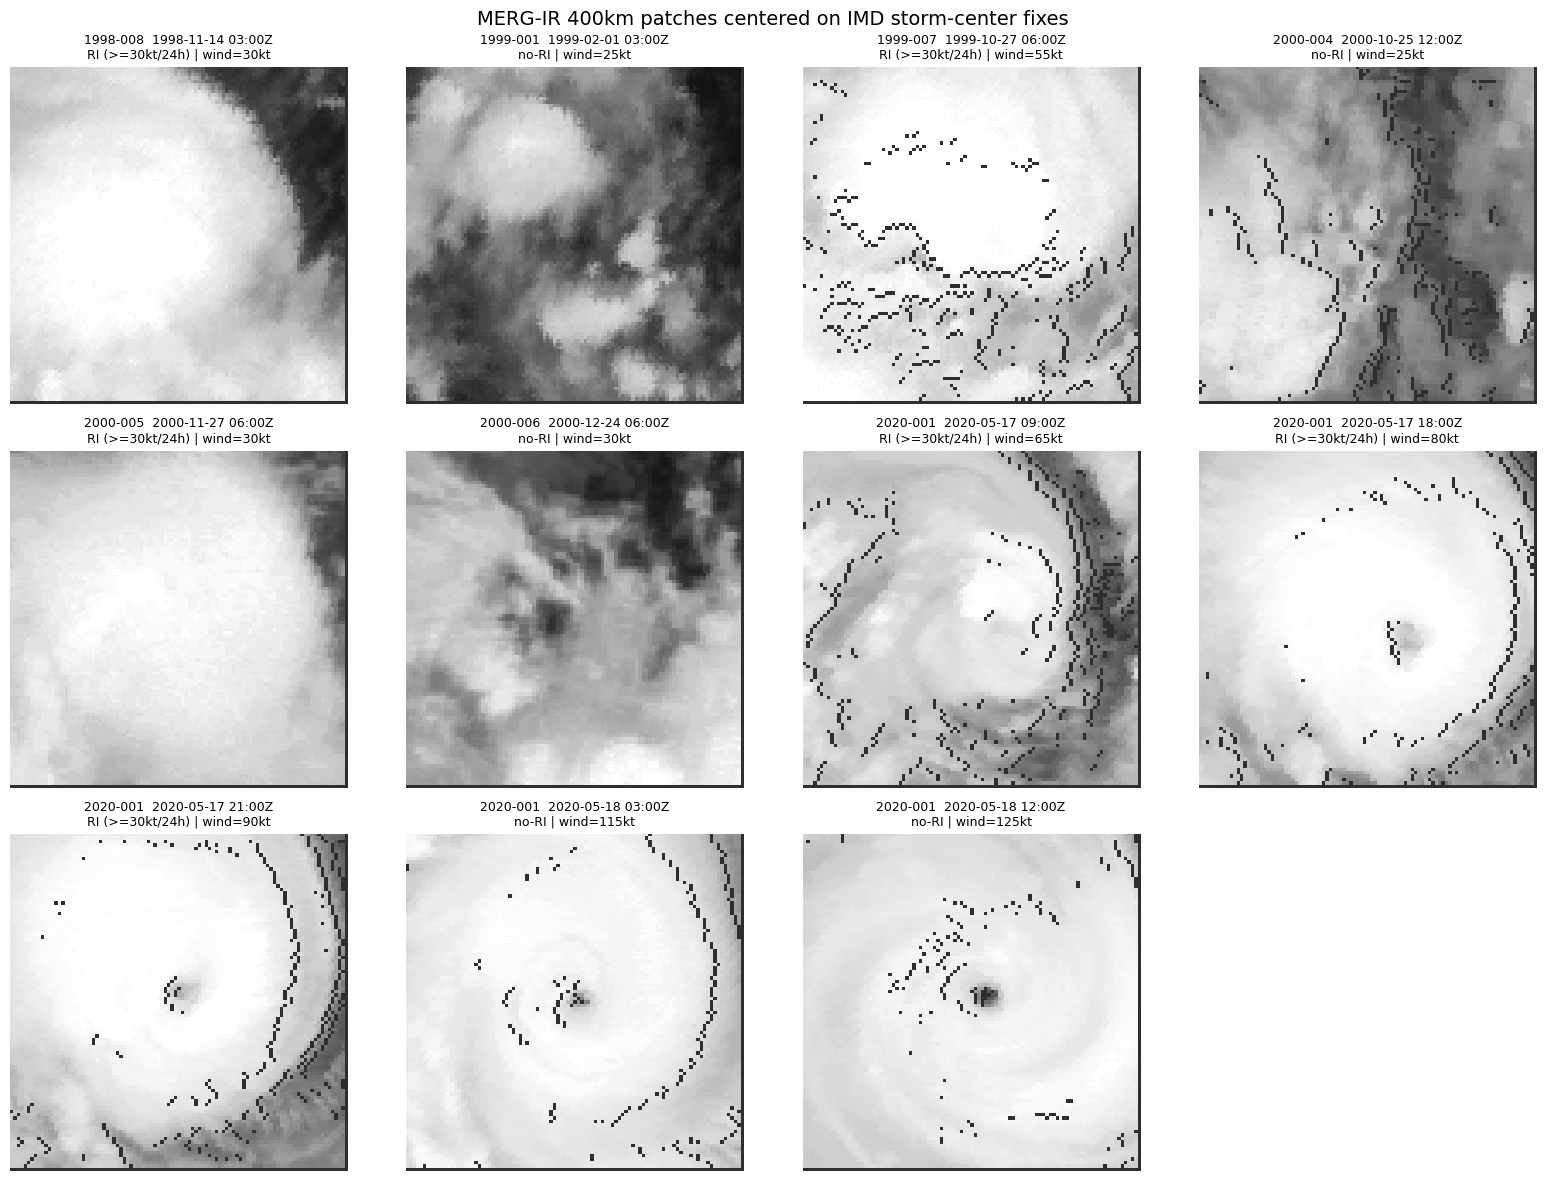

In [4]:
X, y, meta = data["X"], data["y"], data["meta"]
order = np.argsort(meta["datetime_utc"].values)

fig, axes = plt.subplots(3, 4, figsize=(16, 12))
for k, ax in enumerate(axes.flat):
    if k >= len(X):
        ax.axis("off"); continue
    i = order[k]
    ax.imshow(X[i], cmap="gray_r", vmin=190, vmax=300)
    label = "RI (>=30kt/24h)" if y[i] == 1 else "no-RI"
    row = meta.iloc[i]
    ax.set_title(f"{row['storm_id']}  {str(row['datetime_utc'])[:16]}Z\n{label} | wind={row['max_wind_kt']:.0f}kt", fontsize=9)
    ax.axis("off")
plt.suptitle("MERG-IR 400km patches centered on IMD storm-center fixes", fontsize=14)
plt.tight_layout()
plt.show()


## 4. Hybrid CNN + tabular fusion model

See `models/cnn_model.py` for the full architecture and design rationale (shallow CNN + focal loss, chosen for a small, heavily-imbalanced dataset).

In [5]:
from cnn_model import RICNNFusion, FocalLoss
import torch

model = RICNNFusion(tabular_dim=11)
print(model)
n_params = sum(p.numel() for p in model.parameters())
print("\nTrainable parameters:", n_params)


RICNNFusion(
  (ir_encoder): IREncoder(
    (block1): ConvBlock(
      (conv1): Conv2d(2, 16, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
      (bn1): BatchNorm2d(16, eps=1e-05, momentum=0.1, affine=True, bias=True, track_running_stats=True)
      (conv2): Conv2d(16, 16, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
      (bn2): BatchNorm2d(16, eps=1e-05, momentum=0.1, affine=True, bias=True, track_running_stats=True)
      (pool): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
    )
    (block2): ConvBlock(
      (conv1): Conv2d(16, 32, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
      (bn1): BatchNorm2d(32, eps=1e-05, momentum=0.1, affine=True, bias=True, track_running_stats=True)
      (conv2): Conv2d(32, 32, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
      (bn2): BatchNorm2d(32, eps=1e-05, momentum=0.1, affine=True, bias=True, track_running_stats=True)
      (pool): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil

## 5. Train + evaluate end-to-end

> WARNING: With only the 11 sample files this is a **pipeline-correctness demo** (train/test = 8/3 samples), not a statistically meaningful trained model. Run `data/download_mergir.py` (needs normal internet access, e.g. Colab) to build the full archive, then increase `--epochs` and re-run for a real result. Operational RI metrics (POD/FAR/CSI) are reported alongside ROC-AUC / PR-AUC because accuracy is meaningless at ~5% positive rate.

In [6]:
from train import main as train_main

results = train_main(
    nc_folder="/mnt/user-data/uploads",
    epochs=25,
    batch_size=4,
    lr=1e-3,
    out_dir=os.path.join("..","outputs"),
)
results


STEP 1: Rebuild IMD RI tabular dataset (BoB)
STEP 2: Match to available MERG-IR patches


  -> matched patches: 11
STEP 3: Train (8 samples) / Test (3 samples) split


STEP 4: Training
  epoch   1/25 - focal loss: 0.0873


  epoch   2/25 - focal loss: 0.0831
  epoch   4/25 - focal loss: 0.0640


  epoch   6/25 - focal loss: 0.0504
  epoch   8/25 - focal loss: 0.0341


...

  epoch  14/25 - focal loss: 0.0301
  epoch  16/25 - focal loss: 0.0210


  epoch  18/25 - focal loss: 0.0176
  epoch  20/25 - focal loss: 0.0162


  epoch  22/25 - focal loss: 0.0115
  epoch  24/25 - focal loss: 0.0112


STEP 5: Evaluation

RESULTS: {'n_train': 8, 'n_test': 3, 'ROC_AUC': 0.5, 'PR_AUC': 0.5, 'POD': np.float64(1.0), 'FAR': np.float64(0.5), 'CSI': np.float64(0.5), 'TP': np.int64(1), 'FP': np.int64(1), 'FN': np.int64(0), 'TN': np.int64(1)}

Saved model + logs to ../outputs


{'n_train': 8,
 'n_test': 3,
 'ROC_AUC': 0.5,
 'PR_AUC': 0.5,
 'POD': np.float64(1.0),
 'FAR': np.float64(0.5),
 'CSI': np.float64(0.5),
 'TP': np.int64(1),
 'FP': np.int64(1),
 'FN': np.int64(0),
 'TN': np.int64(1)}

## 6. Next steps to make this SIH-ready

1. Run `data/download_mergir.py` on Colab to fetch the full MERG-IR archive for all valid RI fixes (BoB: ~3,000 hourly snapshots, not the full 40-yr global archive).
2. Re-run training with the full archive, `--epochs 50-100`, and storm-grouped k-fold CV.
3. Add multi-frame IR input (t, t-6h, t-12h) - already supported via `ir_channels` in `RICNNFusion`.
4. Add Grad-CAM visualizations of the CNN's attention over the eyewall for the presentation.
5. Compare against your existing XGBoost tabular-only model and the IR-only ablation (`use_tabular=False`) to show the fusion model's improvement quantitatively.